In [2]:
import sys
import numpy as np
import torch 
import pandas as pd
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
import LeafletSC
import pyro 

# Append this directory to sys.path
from LeafletSC.clustering.find_intron_clusters import visualize_local_events
from LeafletSC.beta_binomial_mix.modeling import *
from LeafletSC.beta_binomial_mix.calculate_cellstate_consistency import *
from LeafletSC.clustering.load_cluster_data import *

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import matplotlib.pyplot as plt

from scipy.stats import beta
from sklearn.utils import resample

2.3.0+cu121
12.1
2.3.0+cu121
12.1


In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


In [4]:
# Define path that contains the model input files and append it (input can be a folder with one .h5 file per cell_type for example or one file)
model_input_file='/gpfs/commons/projects/knowles_singlecell_splicing/CZhang_2018_mouse_dev/male_whole_cortex/LeafletAnalysis/mouse_whole_cortex_dev_leaflet.h5'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
     input_file = model_input_file, max_intron_count=100000, remove_singletons=True, has_genes="yes")

# add cluster information to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# generate torch tensors for sparse data representation 
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

# simplify columns 
simple_data = final_data[["cell_id_index", "Cluster", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))
print("The number of cells is: ", len(simple_data.cell_id_index.unique()))

Reading in data from folder ...
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  20857
Number of junctions after removing singletons:  20857
The number of unique cell types in the data is:  9
The number of unique cells in the data is:  18
The number of unique junctions in the data is:  20858
The maximum junction count was initially:  42464
0
The maximum junction count is now:  42464
The number of junctions in the data is:  20858
The number of cells in the data is:  18
The number of cell types in the data is:  9
The number of cells going into training data is:
18
18
The number of junctions is:  20858
The number of intron clusters observed is:  7192
The number of genes is:  5412
The number of cells is:  18


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/LeafletSC/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [5]:
# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [6]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:431.)
  _C._set_default_tensor_type(t)


In [7]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [8]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [9]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [10]:
# how many zeroes in the data compared to total number of values
perc_nonzero = cluster_counts.nnz / (cluster_counts.shape[0] * cluster_counts.shape[1])
print("The percentage of missing values in the intron counts matrix is: ", 1-perc_nonzero)

The percentage of missing values in the intron counts matrix is:  0.03426609560946503


In [131]:
best_K = 3
K = best_K

In [102]:
reload(factor_model)

2.3.0+cu121
12.1


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [132]:
input_conc = None
all_results, variable_sizes = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=5, use_global_prior=True, K=K, lr=0.1, input_conc_prior=input_conc, loss_plot=False, num_epochs=200, save_to_file = False)

INFO:root:No input concentration parameter provided. Using default Gamma(2.0, 2.0) to initialize and learn bb concentration.


Random seeds: [2187, 4492, 6210, 2053, 7820]
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 2187
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 1861920.7324571079
Epoch 40, Elbo loss: 1323110.3369978885
Epoch 80, Elbo loss: 1228148.8193872666
Epoch 120, Elbo loss: 1212351.600342927
Epoch 160, Elbo loss: 1189934.7728096927


INFO:root:Elbo loss: 1182270.4862171672


Sample from the guide (posterior)
Calculate summary statistics
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 4492
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 1842824.8979973153
Epoch 40, Elbo loss: 1316985.6720983596
Epoch 80, Elbo loss: 1221129.85407891
Epoch 120, Elbo loss: 1184661.0158588816
Epoch 160, Elbo loss: 1177017.5924927704


INFO:root:Elbo loss: 1174948.5775416358


...

Stopping early at epoch 186. Best Elbo Loss: 1173246.3560529354
Sample from the guide (posterior)
Calculate summary statistics
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 4 with seed 2053
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 1951626.8331406275
Epoch 40, Elbo loss: 1333344.0107332668
Epoch 80, Elbo loss: 1238851.6354157869
Epoch 120, Elbo loss: 1186289.7527698674
Epoch 160, Elbo loss: 1176188.4260172513


INFO:root:Elbo loss: 1174730.86093021


Stopping early at epoch 183. Best Elbo Loss: 1174134.2279577048
Sample from the guide (posterior)
Calculate summary statistics
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 5 with seed 7820
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 1867784.1900370028
Epoch 40, Elbo loss: 1319459.4885125034
Epoch 80, Elbo loss: 1220638.8616736392
Epoch 120, Elbo loss: 1184332.7112950264
Epoch 160, Elbo loss: 1175740.1859969937


INFO:root:Elbo loss: 1173498.8627018193


Sample from the guide (posterior)
Calculate summary statistics
All initializations complete. Returning results.
------------------------------------------------
Variable sizes: {'bb_conc': torch.Size([]), 'a': torch.Size([20858]), 'b': torch.Size([20858]), 'psi': torch.Size([3, 20858]), 'pi': torch.Size([3]), 'dir_conc': torch.Size([]), 'data': torch.Size([18]), 'assign': torch.Size([18, 3])}


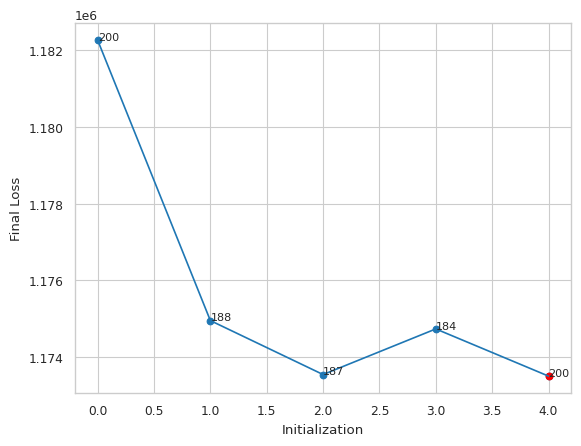

In [133]:
# figure out which index in all_results has the lowest final loss
losses = [result["losses"][-1] for result in all_results]
# get number of epochs for each initialization
num_epochs = [len(result["losses"]) for result in all_results]

# make a quick plot of the losses
plt.plot(losses)
plt.xlabel("Initialization")
plt.ylabel("Final Loss")
# make each loss value with a dot 
plt.scatter(range(len(losses)), losses)
# also mark the number of epochs
for i in range(len(losses)):
    plt.text(i, losses[i], str(num_epochs[i]), size="small")
# mark the lowest loss red
plt.scatter(np.argmin(losses), np.min(losses), color="red")

In [134]:
# Let's get assign matrix for each initialization
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in all_results]
len(assign_matrices)

5

In [135]:
assign_matrices[0].shape

(18, 3)

In [136]:
import numpy as np
from scipy.optimize import linear_sum_assignment

def compare_assignments(assign_matrices):
    num_matrices = len(assign_matrices)
    corrs = np.zeros((num_matrices, num_matrices))
    matchings = {}

    for i in range(num_matrices):
        for j in range(i + 1, num_matrices):

            # Compute correlation matrix between two sets of assignments
            corr_matrix = np.corrcoef(assign_matrices[i].T, assign_matrices[j].T)
            
            # Extract the KxK block that represents the inter-correlations between the assignments
            K = assign_matrices[i].shape[1]  # Number of states
            corr_submatrix = corr_matrix[:K, K:K*2]  # Extracting the cross-correlation part

            # Create cost matrix for maximum correlation assignment (minimizing negative correlation)
            # Cost Matrix: The negative of the correlation matrix is used as the cost matrix because the 
            # linear sum assignment function minimizes the cost. 
            # By negating the correlations, high correlations (close to 1) become low costs (close to -1), which 
            # the algorithm will then minimize, effectively maximizing the correlation.

            cost_matrix = -corr_submatrix

            # Matching: The linear_sum_assignment function from SciPy returns the optimal row and column indices 
            # that minimize the total cost. These indices represent the optimal matching of latent states across the two matrices being compared.

            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            
            # Compute the optimal correlation based on the assignment
            aligned_j = assign_matrices[j][:, col_ind]
            corrs[i, j] = np.corrcoef(assign_matrices[i].flatten(), aligned_j.flatten())[0, 1]
            corrs[j, i] = corrs[i, j]  # Make the matrix symmetric

            # Store the matched pairs
            matchings[(i, j)] = (row_ind, col_ind)
            print(f"Initialization {i+1} vs Initialization {j+1}: Matched pairs {list(zip(row_ind, col_ind))}")

    return corrs, matchings

# Usage
corrs, matchings = compare_assignments(assign_matrices)

Initialization 1 vs Initialization 2: Matched pairs [(0, 0), (1, 2), (2, 1)]
Initialization 1 vs Initialization 3: Matched pairs [(0, 0), (1, 1), (2, 2)]
Initialization 1 vs Initialization 4: Matched pairs [(0, 0), (1, 1), (2, 2)]
Initialization 1 vs Initialization 5: Matched pairs [(0, 2), (1, 0), (2, 1)]
Initialization 2 vs Initialization 3: Matched pairs [(0, 0), (1, 2), (2, 1)]
Initialization 2 vs Initialization 4: Matched pairs [(0, 0), (1, 2), (2, 1)]
Initialization 2 vs Initialization 5: Matched pairs [(0, 2), (1, 1), (2, 0)]
Initialization 3 vs Initialization 4: Matched pairs [(0, 0), (1, 1), (2, 2)]
Initialization 3 vs Initialization 5: Matched pairs [(0, 2), (1, 0), (2, 1)]
Initialization 4 vs Initialization 5: Matched pairs [(0, 2), (1, 0), (2, 1)]


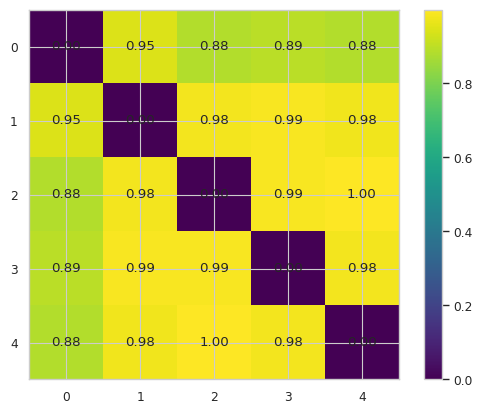

In [137]:
# plot the correlation matrix
plt.imshow(corrs, cmap="viridis")

# add colorbar
plt.colorbar()
# make the ticks show the initialization number
plt.xticks(range(len(corrs)), range(0, len(corrs)))
plt.yticks(range(len(corrs)), range(0, len(corrs)))
# print the correlation values
for i in range(len(corrs)):
    for j in range(len(corrs)):
        plt.text(i, j, f"{corrs[i, j]:.2f}", ha="center", va="center")

In [138]:
def average_pairwise_correlation(corrs):
    # Use tril_indices to access the lower triangle excluding the diagonal
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.mean(corrs[i, j])

def median_pairwise_correlation(corrs):
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.median(corrs[i, j])

def min_pairwise_correlation(corrs):
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.min(corrs[i, j])

# Calculate the average pairwise correlation
average_corr = average_pairwise_correlation(corrs)
print(f"Average Pairwise Correlation: {average_corr}")

consistency_index = average_corr / 1.0  # Since correlation's maximum is 1
print(f"Consistency Index: {consistency_index}")

median_corr = median_pairwise_correlation(corrs)
print(f"Median Pairwise Correlation: {median_corr}")

min_corr = min_pairwise_correlation(corrs)
print(f"Minimum Pairwise Correlation: {min_corr}")

Average Pairwise Correlation: 0.9529469384166349
Consistency Index: 0.9529469384166349
Median Pairwise Correlation: 0.9806489577216493
Minimum Pairwise Correlation: 0.882635191851704


In [139]:
# get the index of initialization with the lowest loss
best_init = np.argmin(losses)
print("The best initialization was: ", best_init)

# extract latent variables for just first seed used 
latent_vars = all_results[best_init]['summary_stats'] 

pi = latent_vars["pi"]["mean"] # overall contribution of each factor to cell population, one value per k
dir_conc = latent_vars["dir_conc"]["mean"] # one scaling value 
assign_post = latent_vars["assign"]["mean"]
psis = latent_vars["psi"]["mean"] # psi is the probability of a junction being used in a cluster
a = latent_vars["a"]["mean"] 
b = latent_vars["b"]["mean"] 
bb_conc = latent_vars["bb_conc"]["mean"] # concentration parameter for beta-binomial distribution

print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))
print("The inferred bb_conc parameter is: " + str(bb_conc))

The best initialization was:  4
[1.1340901  1.0197167  0.79110855 ... 0.81160337 0.19539866 0.6458515 ]
[1.5607266 1.5903876 1.8093231 ... 1.0393379 1.5862137 1.767485 ]
The inferred concentration parameter is: 1.6105891
The inferred pi parameter is: [0.32036927 0.43811312 0.24151762]
The inferred bb_conc parameter is: 158.78432


In [140]:
# compile variable sizes for the model where [] indicates scalar so one value 
params = {}
start_idx = 0

for name, size in variable_sizes.items():
    numel = size.numel()  # Total number of elements in the tensor
    end_idx = start_idx + numel
    params[f"{name}_loc"] = pyro.param("AutoGuideList.0.loc")[start_idx:end_idx]
    params[f"{name}_scale"] = pyro.param("AutoGuideList.0.scale")[start_idx:end_idx]
    start_idx = end_idx

# Print the separated parameters for verification
for key, value in params.items():
    # convert tensor to cpu
    value = value.cpu()
    print(f"{key}: {value.data.numpy()}")
    
# extract the psi_loc and psi_scale values means and standard deviations and convert into K by J 
psi_loc = params["psi_loc"].reshape(K, -1)
psi_scale = params["psi_scale"].reshape(K, -1)

bb_conc_loc: [-0.00098961]
bb_conc_scale: [0.504679]
a_loc: [-0.02912849 -0.3387389  -0.19644828 ... -1.6896789  -0.5577859
  0.41749588]
a_scale: [0.43865865 0.4006807  0.35948196 ... 0.48833692 0.44987285 0.44996077]
b_loc: [ 0.3777982   0.44107738  0.14328355 ...  0.24127021  0.35474014
 -1.2319773 ]
b_scale: [0.36179465 0.45934144 0.282163   ... 0.63337886 0.5052337  0.11620875]
psi_loc: [ 2.3844610e-01 -1.4262875e+00 -4.9218535e-01 ... -7.2263575e+00
  6.8626422e-03 -5.2107550e-02]
psi_scale: [0.11342419 0.15997711 0.23254435 ... 0.789016   0.7934881  0.3185016 ]
pi_loc: [0.5216485 0.4523537 4.13115  ]
pi_scale: [0.2777559  0.22488616 0.04369203]
dir_conc_loc: [3.0407202]
dir_conc_scale: [0.41148198]
data_loc: [ 3.9878707   3.058423    0.44376782 -2.2223213   0.4699265  -1.6134896
  0.18213154 -0.86142784  0.15604618 -0.89073884 -2.3693964   3.0436308
 -2.4177105   2.6648307  -2.122603    3.2061422  -2.5070386   2.8441215 ]
data_scale: [0.02932681 0.39321408 0.00886328 0.03607717 

In [141]:
plot_bb = True

In [142]:
latent_vars["bb_conc"]

{'mean': array(158.78432, dtype=float32),
 'std': array(5.907572, dtype=float32),
 '5%': 149.15216979980468,
 '95%': 168.2584144592285}

In [143]:
latent_vars["psi"]["mean"].shape # K by J 

(3, 20858)

In [144]:
# get all names or keys inside latent_vars
latent_vars.keys()

dict_keys(['data', '_AutoGuideList.0_latent', 'a', 'b', 'psi', 'pi', 'dir_conc', 'assign', '_AutoGuideList.1_latent', 'bb_conc'])

<Axes: >

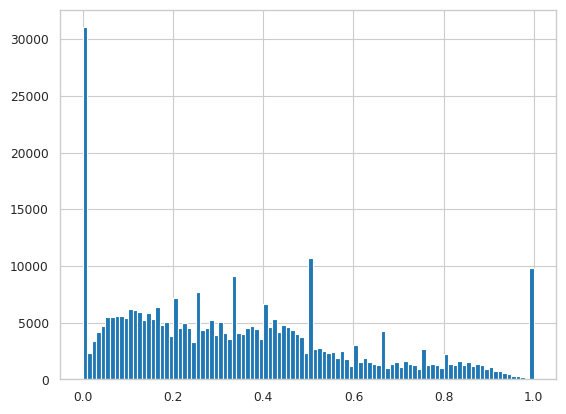

In [145]:
final_data.juncratio.hist(bins=100)

In [146]:
np.random.randint(J)

11083

In [147]:
psis.shape

(3, 20858)

The bb conc param is 158.78431701660156
The average junction behaviour is: 0.42


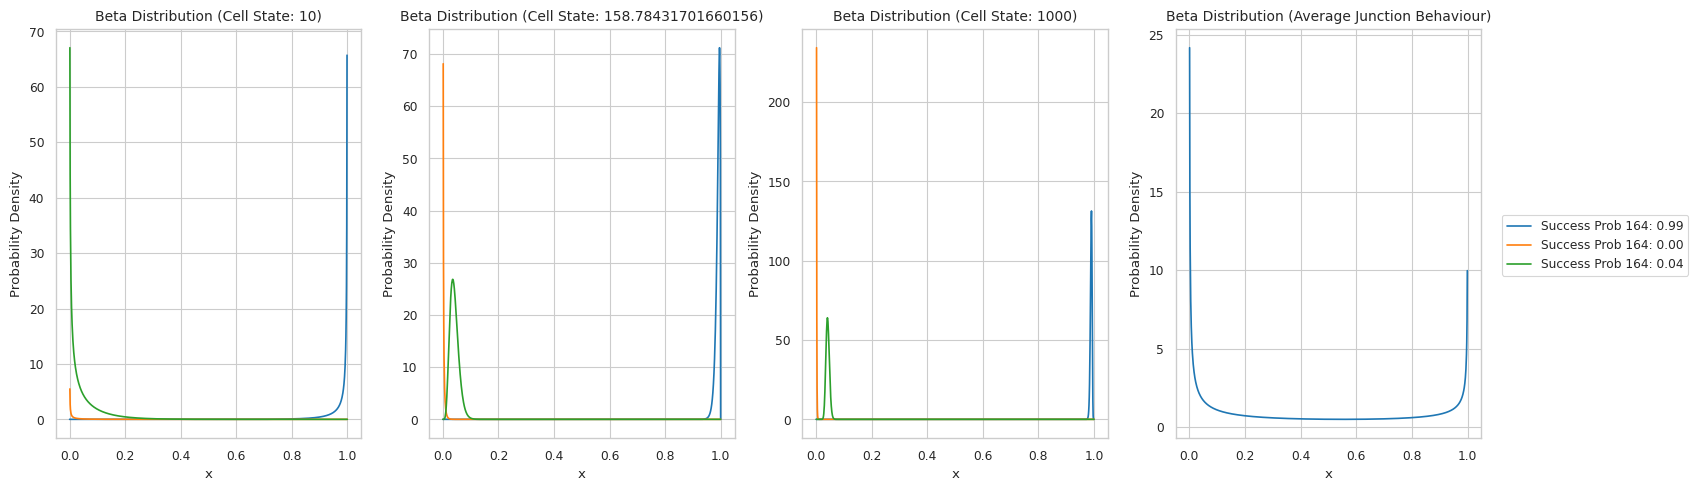

In [148]:
J = psis.shape[1]
jj = np.random.randint(J)
jj = 163
if plot_bb:

    # Generate values for the x-axis
    x = np.linspace(0, 1, 1000)

    success_probs = psis[:,jj]
    bbconc_param = bb_conc
    print(f"The bb conc param is {bbconc_param}")
    conc_params = [10, bbconc_param, 1000]
    fig, axs = plt.subplots(1, 4, figsize=(15, 5))
    # Define a single legend for all curves
    legend_labels = []

    for i, conc_param in enumerate(conc_params):

        # Plot individual curves for each success probability
        for j, success_prob in enumerate(success_probs):
            # Calculate shape parameters for the Beta distribution
            bb_alpha = success_prob * conc_param
            bb_beta = (1 - success_prob) * conc_param

            # Calculate the probability density function (PDF) of the beta distribution
            pdf = beta.pdf(x, bb_alpha, bb_beta)

            # Plot the Beta distribution
            # axs[i].plot(x, pdf, label=f'Success Prob {j+1}: {success_prob:.2f}')
            # Plot the Beta distribution and store the label for the legend
            line, = axs[i].plot(x, pdf, label=f'Success Prob {jj+1}: {success_prob:.2f}')
            if i == 0:  # Add legend labels only once
                legend_labels.append(line.get_label())
            
        axs[i].set_title(f'Beta Distribution (Cell State: {conc_param})', fontsize=10)
        axs[i].set_xlabel('x')
        axs[i].set_ylabel('Probability Density')
        axs[i].grid(True)

    # Also plot the Beta distribution average junction behaviour using a_j and b_j values
    # in this case just a[1] and b[1] for the current junction 
    bb_alpha = a[jj]
    bb_beta = b[jj]
    bb_avg = bb_alpha / (bb_alpha+bb_beta)
    print(f"The average junction behaviour is: {bb_avg:.2f}")
    pdf = beta.pdf(x, bb_alpha, bb_beta)
    axs[3].plot(x, pdf, label=f'Average Junction Behaviour')
    axs[3].set_title('Beta Distribution (Average Junction Behaviour)', fontsize=10)
    axs[3].set_xlabel('x')
    axs[3].set_ylabel('Probability Density')
    axs[3].grid(True)
    
    # extract only unique values from legend lines 
    fig.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    # print the plot
    # print axs[2]

    plt.show()

In [26]:
# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

# run UMAP on assign_post matrix
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

In [27]:
samples_order = ["E14.5", "E16.5", "P0", "P4", "P7", "P15", "P30", "P110", "21M"]

['E14.5', 'E16.5', 'P0', 'P4', 'P7', 'P15', 'P30', 'P110', '21M']


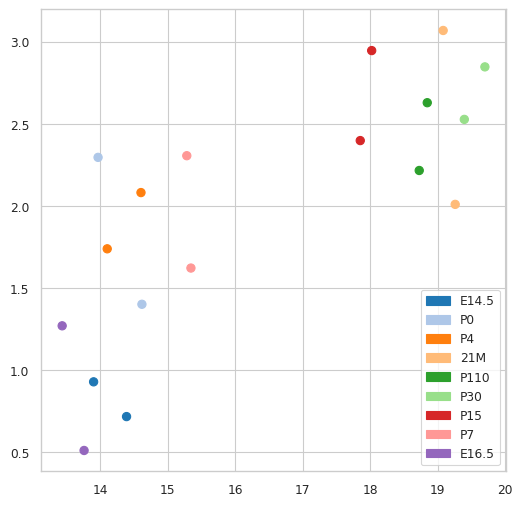

In [28]:
# plot UMAP 
# add whitegrid 
import matplotlib.patches as mpatches

sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))

cell_types = cell_ids_conversion.cell_type

cell_types_unique = cell_types.unique()
cell_type_colors = sns.color_palette("tab20", len(cell_types_unique))
cell_type_dict = dict(zip(cell_types_unique, cell_type_colors))
cell_colors = cell_types.map(cell_type_dict)

# Plot the UMAP embedding
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=35, c=cell_colors
)

# Create legend handles and labels
legend_handles = [mpatches.Patch(color=color, label=cell_type) for cell_type, color in cell_type_dict.items()]

# Add legend to the plot
plt.legend(handles=legend_handles)

print(samples_order)

In [ ]:
# giw dies UMAP look for gene expression data? 

In [ ]:
pi

         pi    Factor
3  0.457865  Facotor3
2  0.157370  Facotor2
4  0.085777  Facotor4
0  0.061615  Facotor0
1  0.057779  Facotor1


/scratch/ipykernel_77608/415432497.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")


Text(0.5, 1.0, 'Overall contribution of each factor to cell population')

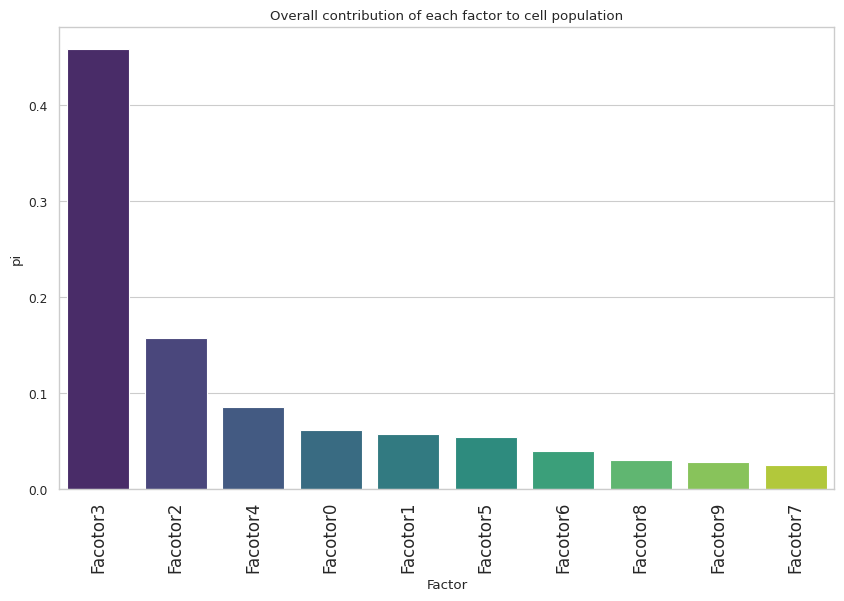

In [29]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=12)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")

In [30]:
# how many cell states get a contribution of at least 0.01 
print("The number of cell states with a contribution of at least 0.01 is: ", len(pi_df[pi_df.pi >= 0.01]))

# let's use that number as the next iterations of K 
new_K = len(pi_df[pi_df.pi >= 0.01])
print("The new K is: ", new_K)

The number of cell states with a contribution of at least 0.01 is:  10
The new K is:  10


In [32]:
# convert into a data frame
psi_df = pd.DataFrame(psis)

In [33]:
# make a new column wiht values from 1 to 9 to indiciate numerically the cell types in order E14.5 should be 1 and 21M should be 9 
cell_ids_conversion["cell_type_num"] = cell_ids_conversion.cell_type.replace(dict(zip(samples_order, range(1, 10))))

/scratch/ipykernel_77608/31783681.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cell_ids_conversion["cell_type_num"] = cell_ids_conversion.cell_type.replace(dict(zip(samples_order, range(1, 10))))


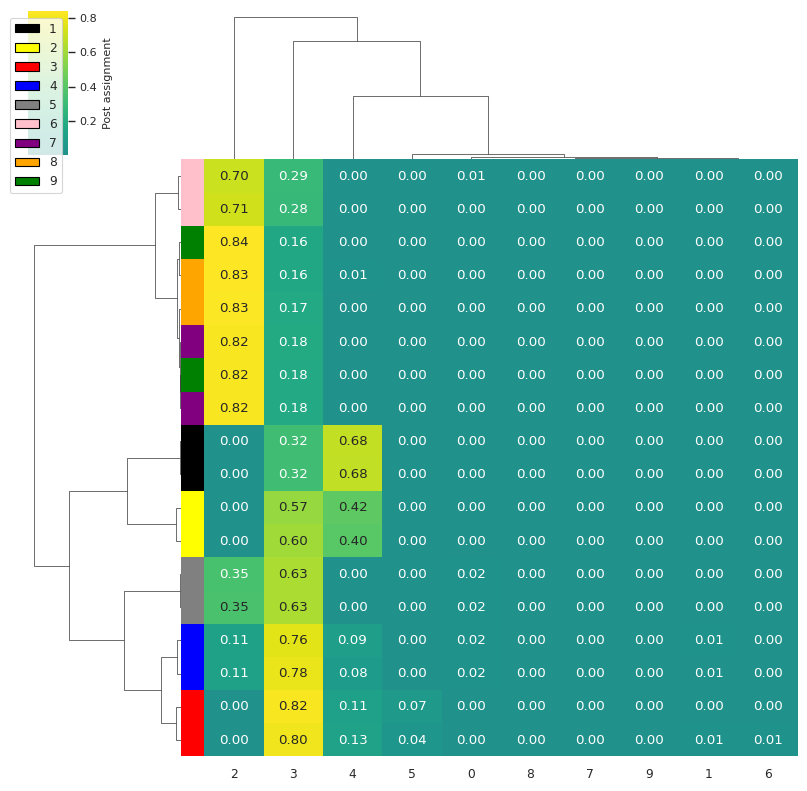

In [34]:
import seaborn as sns
from matplotlib.patches import Patch

# Define your custom color palette
custom_palette = ["black", "red", "blue", "green", "orange", "purple", "pink", "grey", "yellow"]

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type_num'].unique()
num_unique_types = len(unique_cell_types)
colors = custom_palette[:num_unique_types]  # Ensure you have enough colors in your custom palette

# Create a dictionary mapping cell types to colors
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}

# Get cell type labels for each cell
cell_types = cell_ids_conversion.cell_type_num.values

# Create a list of colors for each cell based on its cell type
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

# Use the custom color palette in your clustermap
cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=True,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
)

# Set label for color bar
cluster.cax.set_ylabel('Post assignment', size=8)

# Increase font size for color bar tick labels
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

legend_elements = [Patch(facecolor=cell_type_colors[key], edgecolor='black', label=str(key)) for key in sorted(cell_type_colors.keys())]
plt.legend(handles=legend_elements, loc='upper right')


In [ ]:
from scipy.stats import beta

def assess_significance_individual(observed_psi_kj, a_j, b_j, num_iterations=1000, alpha=0.05):
    """
    Assess the significance of individual observed PSI values for a given junction compared to its average behavior,
    using a Beta distribution defined by parameters a_j and b_j.

    Parameters:
    - observed_psi_kj (array-like): Observed PSI values for the junction in a specific cell state.
    - a_j (float): Parameter 'a' representing the average behavior across all cell states.
    - b_j (float): Parameter 'b' representing the average behavior across all cell states.
    - num_iterations (int, optional): Number of iterations for bootstrap resampling. Defaults to 100.
    - alpha (float, optional): Significance level for confidence intervals. Defaults to 0.05.

    Returns:
    - results_sig (list of bool): List indicating significance for each observed PSI.
    - confidence_interval (tuple): Confidence interval for the average PSI.
    """
    
    # Generate bootstrap samples from the Beta distribution defined by a_j and b_j
    bootstrap_samples = beta.rvs(a_j, b_j, size=num_iterations)

    # Get likelihood of observing observed_psi_kj values under a_j and b_j
    pdf_values = beta.pdf(observed_psi_kj, a_j, b_j)

    # Calculate the confidence interval for the bootstrap samples
    lower_bound = np.percentile(bootstrap_samples, (alpha / 2) * 100)
    upper_bound = np.percentile(bootstrap_samples, (1 - alpha / 2) * 100)
    confidence_interval = (lower_bound, upper_bound)

    # Assess if each observed PSI value is outside the confidence interval
    results_sig = [(psi < lower_bound or psi > upper_bound) for psi in observed_psi_kj]

    # Average baseline junction 
    avg_j = a_j/(a_j+b_j)

    return results_sig, confidence_interval, avg_j, pdf_values

In [ ]:
J = junction_ids_conversion.shape[0]

# Initialize lists to store results
junction_ids = []
observed_psis_list = []
mean_junc = []
is_significant_list = []
conf_int_list = []
pdf_values = []

# Iterate over each junction
for j in tqdm(range(J)):
    observed_psis = psi[:, j]
    a_j = a[j]
    b_j = b[j]

    # Assess significance for the current junction
    junc_sig, confidence_intervals, avg_junc, pdf_vals = assess_significance_individual(observed_psis, a_j, b_j, num_iterations=300, alpha=0.05)

    # Append results to lists
    junction_ids.append(j)
    observed_psis_list.append(observed_psis)
    mean_junc.append(avg_junc)
    is_significant_list.append(junc_sig)
    conf_int_list.append(confidence_intervals)
    pdf_values.append(pdf_vals)

# Create a DataFrame from the lists
results_df = pd.DataFrame({
    'Junction_ID': junction_ids,
    'Observed_PSI': observed_psis_list,
    'mean_junc': mean_junc,
    'Is_Significant': is_significant_list,
    'Confidence_Intervals': conf_int_list,
    'pdf_values': pdf_values
})

In [ ]:
# Assuming 'results_df' is already defined and contains the 'Is_Significant' data as described

# Convert the 'Is_Significant' column, which is a list of lists, into a DataFrame
is_significant_df = pd.DataFrame(results_df['Is_Significant'].tolist())

# Calculate the proportion of True values for each junction
# `mean(axis=0)` will calculate the mean down the columns, i.e., across all junctions
proportion_significant = is_significant_df.sum(axis=1)

# Add the proportion_significant column to the original DataFrame
results_df['Proportion_Significant'] = proportion_significant

# Sort the DataFrame based on the proportion of significant values, in descending order
sorted_df = results_df.sort_values(by='Proportion_Significant', ascending=False)

In [ ]:
psi_df = pd.DataFrame(psi.T)

In [ ]:
sorted_df.head()

In [ ]:
def plot_psi_with_confidence_interval(mean_junc, conf_int, psi_values, junction_id):
    """
    Plot the PSI values for a junction with the mean and confidence interval.

    Parameters:
    - mean_junc (float or Series): The mean PSI value for the junction.
    - conf_int (tuple or Series): The confidence interval (lower, upper) for the mean PSI.
    - psi_values (list or array): List or array of individual PSI values for the junction.
    - junction_id (int): Identifier for the junction.
    """
    # Check if mean_junc or conf_int are pandas Series and extract values if necessary
    if isinstance(mean_junc, pd.Series):
        mean_junc = mean_junc.iloc[0]  # Assuming mean_junc is a single value in a Series
    if isinstance(conf_int, pd.Series):
        conf_int = conf_int.iloc[0]  # Assuming conf_int is a tuple inside a Series
    
    # Extract lower and upper bounds from the confidence interval
    lower, upper = conf_int
    plt.figure(figsize=(6, 6))
    
    # get gene name that junction is in 
    gene_name = junction_ids_conversion[junction_ids_conversion["junction_id_index"] == j].gene_id.values
    junction_id = junction_ids_conversion[junction_ids_conversion["junction_id_index"] == j].junction_id.values
    print(j, gene_name, junction_id)
    
    plt.title(f"PSI Visualization for Junction {j} in \nGene {gene_name} ({junction_id})")
    plt.xlabel("Cell States")
    plt.ylabel("PSI Values")
    
    # Extract lower and upper bounds from the confidence interval
    lower, upper = conf_int
    
    # Plot the mean junction PSI as a red dot
    plt.scatter([-0.5], [mean_junc], color='red', zorder=5, label='Mean PSI')
    
    # add the confidence interval on mean junc using lower and upper should be vertical
    plt.vlines(x=-0.5, ymin=lower, ymax=upper, color='grey', linestyle='--', label='Confidence Interval')
    
    # Plot the individual PSI values
    plt.scatter(range(len(psi_values)), psi_values, color='blue', label='Individual PSI Values')
    
    # make ylim be 0 to 1 
    plt.ylim(0, 1)
    
    # Add legend and improve layout
    plt.legend()
    plt.grid(True)
    plt.xticks(range(len(psi_values)), labels=[f"{i+1}" for i in range(len(psi_values))])
    plt.show()

In [ ]:
# let's write a function that plots junction usage ratio across cell types for a given junction 
j = np.random.choice(J)
j = 0
# plot juncratio across cell types
quick_plot_data = simple_data[simple_data.junction_id_index == j]
quick_plot_data = quick_plot_data.merge(cell_ids_conversion, on=["cell_id_index"], how="left")

# print the number of cells that have this junction expressed 
print("The number of cells that have junction ", j, " expressed is: ", quick_plot_data.cell_id.nunique())

# print result from significance analysis
print(sorted_df[sorted_df["Junction_ID"] == j])

plt.figure(figsize=(6, 6))
sns.boxplot(x="cell_type_num", y="juncratio", data=quick_plot_data, palette="viridis")
plt.title("Junction usage ratio across cell types for junction "+str(j))
# make the ylim be 0 to 1
plt.ylim(0, 1)

# plot also baseline average junction usage which is a_j / (a_j+b_j) 
avg_junc = a[j] / (a[j] + b[j])
print(avg_junc)

# add a red dot indicating the avg_junc 
# Add a red dot indicating the avg_junc
plt.scatter(x=[-1], y=[avg_junc], color='red', label='Average Junction Usage')

# add xlab "Developmental Time Point"
plt.xlabel("Developmental Time Point")

# Show the plot
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
j = 1
mean_junc = sorted_df[sorted_df["Junction_ID"] == j].mean_junc
conf_int = sorted_df[sorted_df["Junction_ID"] == j].Confidence_Intervals
psi_values = psi_df.iloc[j]
plot_psi_with_confidence_interval(mean_junc, conf_int, psi_values, j)

In [ ]:
# now further filter to only include junctions that are significant in cell state 1 and no other cell state
cell_state1 = sorted_df[sorted_df["Proportion_Significant"] == 1]
cell_state1 = cell_state1[cell_state1["Is_Significant"].apply(lambda x: x[0])]

In [ ]:
cell_state1

In [ ]:
# get junctions ids 
juncs_state1 = cell_state1.Junction_ID.values

# extract PSI values for these junctions across all cell states 
psis_state1 = psi[:,juncs_state1]

In [ ]:
sns.clustermap(psis_state1)

In [ ]:
# now check psis_state1 junctions how they are expresed in real data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_junction_usage(junction_id, simple_data, cell_ids_conversion, sorted_df, a, b):
    # Filter data for the given junction
    quick_plot_data = simple_data[simple_data.junction_id_index == junction_id]
    quick_plot_data = quick_plot_data.merge(cell_ids_conversion, on=["cell_id_index"], how="left")

    # Print the number of cells that have this junction expressed
    print("The number of cells that have junction", junction_id, "expressed is:", quick_plot_data.cell_id.nunique())

    # Print result from significance analysis
    print(sorted_df[sorted_df["Junction_ID"] == junction_id])

    # Plot junction usage ratio across cell types
    plt.figure(figsize=(6, 6))
    sns.boxplot(x="cell_type_num", y="juncratio", data=quick_plot_data, palette="viridis")
    plt.title("Junction usage ratio across cell types for junction " + str(junction_id))
    # Set the y-axis limits to be between 0 and 1
    plt.ylim(0, 1)

    # Plot baseline average junction usage which is a_j / (a_j+b_j)
    avg_junc = a[junction_id] / (a[junction_id] + b[junction_id])
    print(avg_junc)

    # Add a red dot indicating the avg_junc
    plt.scatter(x=[-1], y=[avg_junc], color='red', label='Average Junction Usage')

    # Add x-label "Developmental Time Point"
    plt.xlabel("Developmental Time Point")

    # Show legend
    plt.legend()

    # Show the plot
    plt.grid(True)
    plt.show()

In [ ]:
cell_state1

In [ ]:
plot_junction_usage(0, simple_data, cell_ids_conversion, sorted_df, a, b)

In [ ]:
junction_ids_conversion[junction_ids_conversion.junction_id_index == juncs_state1[10]]

In [ ]:
junction_ids_conversion[junction_ids_conversion.Cluster == 25871]

In [ ]:
plot_junction_usage(18209, simple_data, cell_ids_conversion, sorted_df, a, b)

In [ ]:
plot_junction_usage(9998, simple_data, cell_ids_conversion, sorted_df, a, b)

In [ ]:
# Functions for differential splicing analysis 
def log_beta_torch(a, b):
    
    """
    Computes the logarithm of the beta function for given alpha and beta parameters.

    Args:
    a (Tensor): Alpha parameters of the beta distribution.
    b (Tensor): Beta parameters of the beta distribution.

    Returns:
    Tensor: Logarithm of the beta function evaluated at (a, b).
    """
        
    return torch.lgamma(a) + torch.lgamma(b) - torch.lgamma(a + b)

def score_torch(a, b):
    
    """
    Computes the differential splicing score as the difference between the sum of log beta functions
    for each cell state and the log beta function of summed parameters across all states.

    Args:
    a (Tensor): Alpha parameters for each cell state.
    b (Tensor): Beta parameters for each cell state.

    Returns:
    Tensor: Differential splicing score.
    """
    
    return log_beta_torch(a, b).sum() - log_beta_torch(a.sum(), b.sum())

# Add functionality for getting score q-value to measure significance of differential splicing
def differential_splicing_torch(PSI_kj, a_j, b_j, bb_conc):

    """
    Analyzes differential splicing across cell states by comparing local splicing levels to global averages.

    Args:
    PSI_kj (Tensor or array): Posterior mean inclusion levels for each junction in each cell state.
    a_j (Tensor or array): Alpha parameters from a global perspective for each junction.
    b_j (Tensor or array): Beta parameters from a global perspective for each junction.
    bb_conc (Tensor or array): Global beta-binomial concentration parameter.

    Returns:
    tuple: Approximate log Bayes factor (ALBF) indicating likelihood of differential splicing across cell states,
           and the contribution score for each cell state to the overall variability in splicing.

    Notes:
    - ALBF: Higher values suggest a higher likelihood of differential splicing across cell states.
    - Factor contribution score: Measures the contribution of each cell state's PSI to the total variability,
      scaled by the beta-binomial concentration parameter. It is useful for identifying specific states
      with significant deviations from the global behavior.
    """
    
    # Ensure inputs are torch tensors
    PSI_kj = torch.tensor(PSI_kj, dtype=torch.float32) if not isinstance(PSI_kj, torch.Tensor) else PSI_kj
    a_j = torch.tensor(a_j, dtype=torch.float32) if not isinstance(a_j, torch.Tensor) else a_j
    b_j = torch.tensor(b_j, dtype=torch.float32) if not isinstance(b_j, torch.Tensor) else b_j
    bb_conc = torch.tensor(bb_conc, dtype=torch.float32) if not isinstance(bb_conc, torch.Tensor) else bb_conc
    
    # Compute global average PSI using junction-specific parameters
    global_avg_psi = a_j / (a_j + b_j)

    # Calculate alpha and beta values for each cell state based on the global shape parameters
    alpha_kj = PSI_kj * a_j
    beta_kj = (1 - PSI_kj) * b_j

    # Calculate ALBF score for junction 
    ALBF = score_torch(alpha_kj, beta_kj)

    # Compute factor contribution scores
    factor_contributes = ((PSI_kj - global_avg_psi)**2) * bb_conc 

    return ALBF, factor_contributes 

In [ ]:
# For each PSI_jk we can compare it to the average PSI_j across all cell states (average global behaviour)
# To see if it is significantly different from the average behaviour 

# We can use the score function to calculate the log-likelihood ratio of the observed PSI_jk values under the average behaviour
# compared to the observed behaviour in cell state k

print(a) #one for each junction 
print(b)

In [ ]:
# let's just look at the first junction
j = 11278

# get learned PSIs for this junction 
psi_j = psi[:,j] # K vector

# get our beta binomial concentration parameter
bb_conc = latent_vars["bb_conc"]["mean"] # one value 

In [ ]:
print(a[j], b[j], psi_j)

In [ ]:
differential_splicing_torch(psi_j, a[j], b[j], bb_conc)

In [ ]:
sorted_df

In [ ]:
# for each junction in J, calculate differential_splicing_torch
differential_splicing_scores = []
for j in tqdm(range(J)):
    psi_j = psi[:,j]
    score1, factor_j = differential_splicing_torch(psi_j, a[j], b[j], bb_conc)
    differential_splicing_scores.append([score1.item(), factor_j])

In [ ]:
# convert to dataframe 
differential_splicing_scores_df = pd.DataFrame(differential_splicing_scores, columns=["score1", "factor_j"])

# add junction ID column 
differential_splicing_scores_df["junction_id_index"] = range(J)

In [ ]:
# sort the dataframe by differential splicing score score 2 
differential_splicing_scores_df = differential_splicing_scores_df.sort_values(by='score1', ascending=False)

In [ ]:
differential_splicing_scores_df["score1_qvalue"] = 1/differential_splicing_scores_df["score1"]

In [ ]:
differential_splicing_scores_df.score1.hist()

In [ ]:
sns.histplot(differential_splicing_scores_df["score1_qvalue"], bins = 100)

In [ ]:
# what is the 0.95 quantile of the differential splicing scores
q975 = differential_splicing_scores_df["score1"].quantile(0.975)
print("The 0.975 quantile of the differential splicing scores is: ", q975)
q025 = differential_splicing_scores_df["score1"].quantile(0.025)
print("The 0.025 quantile of the differential splicing scores is: ", q025)

In [ ]:
# Find all the junctions that have a differential splicing score above the 0.975 quantile or less than the 0.025 quantile
significant_junctions = differential_splicing_scores_df[(differential_splicing_scores_df["score1"] > q975) | (differential_splicing_scores_df["score1"] < q025)]
significant_junctions = significant_junctions[significant_junctions["score1_qvalue"] < 0.05]

In [ ]:
significant_junctions

In [ ]:
bb_conc_param = bb_conc

In [ ]:
def plot_beta_distribution(jj, psis, a, b, bb_conc_param):
    
    # Generate values for the x-axis
    x = np.linspace(0, 1, 1000)

    # Plot individual curves for each success probability
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Plot the Beta distribution for average junction behavior
    bb_alpha_avg = a[jj]
    bb_beta_avg = b[jj]
    bb_avg = bb_alpha_avg / (bb_alpha_avg + bb_beta_avg)
    pdf_avg = beta.pdf(x, bb_alpha_avg, bb_beta_avg)
    axs[0].plot(x, pdf_avg, label=f'Average Junction Behaviour')
    axs[0].set_title('Beta Distribution (Average Junction Behaviour)')
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('Probability Density')
    axs[0].grid(True)

    # Plot the Beta distribution based on the learned concentration parameter
    bb_alpha_conc = psis[:, jj] * bb_conc_param
    bb_beta_conc = (1 - psis[:, jj]) * bb_conc_param
    for i in range(len(bb_alpha_conc)):
        pdf_conc = beta.pdf(x, bb_alpha_conc[i], bb_beta_conc[i])
        axs[1].plot(x, pdf_conc, label=f'Success Prob {i+1}: {psis[i, jj]:.2f}')
    axs[1].set_title(f'Beta Distribution (Cell State: {bb_conc_param})')
    axs[1].set_xlabel('x')
    axs[1].set_ylabel('Probability Density')
    axs[1].grid(True)

    # Add legends
    axs[0].legend()
    axs[1].legend()

    plt.tight_layout()
    plt.show()


In [ ]:
bb_conc_param

In [ ]:
jj = significant_junctions.sample(1).junction_id_index.values[0]
# pint result for this junction id from the scores table
print(differential_splicing_scores_df[differential_splicing_scores_df.junction_id_index == jj])
plot_beta_distribution(jj, psis, a, b, bb_conc_param)

In [ ]:
j = jj
psi_j = psi[:,j]
score1, cons = differential_splicing_torch(psi_j, a[j], b[j], bb_conc)
# convert cons to dataframe and add column for cell state 1 to K
cons_df = pd.DataFrame(cons.cpu(), columns=["cons"])
cons_df["cell_state"] = range(1, K+1)
# sort by cons
cons_df = cons_df.sort_values(by="cons", ascending=False)
cons_df

In [ ]:
# add column for differential_splicing_scores_df whether score2 is significant or not 
differential_splicing_scores_df["significant"] = differential_splicing_scores_df["junction_id_index"].apply(lambda x: x in significant_junctions.junction_id_index.values)

In [ ]:
differential_splicing_scores_df

In [ ]:
# plot correlation between score1 and score 2
sns.relplot(x='score1', y='score2', hue='significant', data=differential_splicing_scores_df)
plt.title('Score1 vs Score2')